## Train a CNN Model on Images from Google Drive

This notebook demonstrates how to load an image dataset from Google Drive, build a Convolutional Neural Network (CNN) using TensorFlow/Keras, train the model, and evaluate its performance.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

### 2. Load and Preprocess the Dataset

We'll use `tf.keras.utils.image_dataset_from_directory` to load images directly from the specified directory. It's assumed your dataset is organized in subdirectories, where each subdirectory name is a class label.

We'll also define image size and batch size, and rescale the pixel values.

In [2]:
DATA_DIR = '/content/drive/MyDrive/Dataset_augmented'
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Check if the directory exists
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR}")

# Load the dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = dataset.class_names
print(f"Found {len(class_names)} classes: {class_names}")

# Preprocessing: Rescale pixel values from [0, 255] to [0, 1]
def preprocess_image(image, label):
    # First cast to float32, then divide
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset = dataset.map(preprocess_image)

# Configure dataset for performance
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 4000 files belonging to 4 classes.
Found 4 classes: ['Angry', 'Happy', 'Neutral', 'Sad']


### 3. Split the Dataset

We'll split the dataset into training, validation, and test sets. A common split is 80% for training, 10% for validation, and 10% for testing.

In [3]:
DATASET_SIZE = tf.data.experimental.cardinality(dataset).numpy()
TRAIN_SIZE = int(0.8 * DATASET_SIZE)
VAL_SIZE = int(0.1 * DATASET_SIZE)

# Create splits
train_ds = dataset.take(TRAIN_SIZE)
remaining_ds = dataset.skip(TRAIN_SIZE)
val_ds = remaining_ds.take(VAL_SIZE)
test_ds = remaining_ds.skip(VAL_SIZE)

# Apply cache and prefetch (Removed .repeat() entirely)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Training batches: 100
Validation batches: 12
Test batches: 13


### 4. Build the CNN Model

Here, we'll define a simple CNN architecture using Keras Sequential API. You can modify this architecture based on your specific dataset and needs.

In [4]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # Use softmax for multi-class classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Compile the Model

We need to specify the optimizer, loss function, and metrics for training.

In [5]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### 6. Train the Model

Now, we'll train the model using the `fit` method. You can adjust the number of `epochs`.

In [6]:
EPOCHS = 10 # You can increase this for better performance

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 544s 5s/step - accuracy: 0.3178 - loss: 1.4076 - val_accuracy: 0.4349 - val_loss: 1.2503
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 595ms/step - accuracy: 0.5175 - loss: 1.1312 - val_accuracy: 0.7083 - val_loss: 0.8622
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 611ms/step - accuracy: 0.6994 - loss: 0.7740 - val_accuracy: 0.7708 - val_loss: 0.6086
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 601ms/step - accuracy: 0.7769 - loss: 0.5750 - val_accuracy: 0.8568 - val_loss: 0.4629
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 594ms/step - accuracy: 0.8425 - loss: 0.4319 - val_accuracy: 0.8255 - val_loss: 0.4860
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 588ms/step - accuracy: 0.8731 - loss: 0.3498 - val_accuracy: 0.8776 - val_loss: 0.3800
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 574ms/step - accuracy: 0.9019 - loss: 0.2739 - val_accuracy: 0.8646 - val_loss: 0.4040
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 584ms/step - accuracy: 0.9100 - loss: 0.2

### 7. Evaluate the Model

After training, we'll evaluate the model's performance on the unseen test set.

In [7]:
print("\nEvaluating the model on the test set:")
# return_dict=True packages all metrics into a dictionary
results = model.evaluate(test_ds, return_dict=True)

# Check if results actually contain data before printing
if results:
    print(f"Test Loss: {results.get('loss', 'N/A'):.4f}")
    print(f"Test Accuracy: {results.get('compile_metrics', results.get('accuracy', 'N/A')):.4f}")
else:
    print("Evaluation failed: The dataset yielded 0 batches.")


Evaluating the model on the test set:
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8365 - loss: 0.5488
Test Loss: 0.5488
Test Accuracy: 0.8365


### 8. Visualize Training History

Plotting the training and validation accuracy and loss over epochs can help understand the model's learning process.

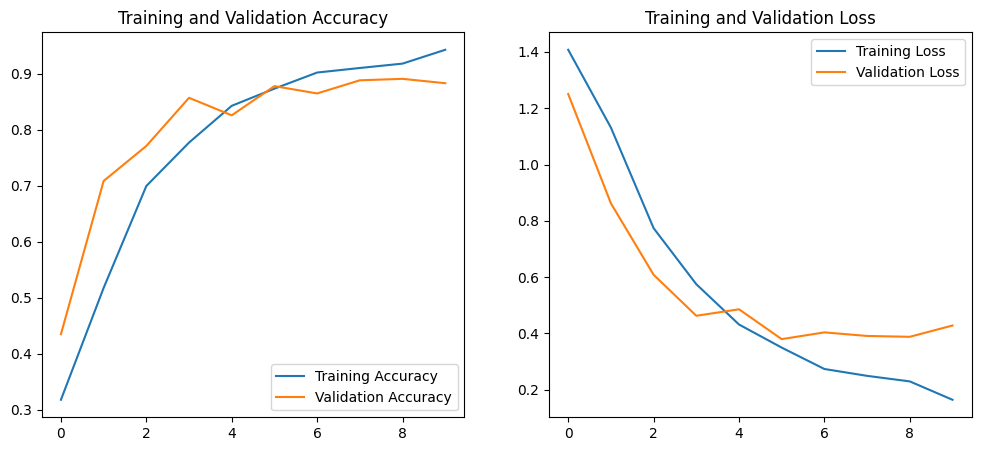

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Make the range dynamic based on actual completed epochs
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

This script provides a solid foundation for training your CNN. You might want to experiment with:

*   **Data Augmentation**: Adding more data augmentation layers to `tf.keras.Sequential`.
*   **Model Architecture**: Adding more layers, changing filter sizes, using different activation functions.
*   **Hyperparameters**: Adjusting learning rate, batch size, and number of epochs.
*   **Transfer Learning**: Using pre-trained models like ResNet or VGG for better performance on smaller datasets.

In [10]:
model_save_path = '/content/saved_model.keras'
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/saved_model.keras
